In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate ,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:

df = pd.read_csv(r"predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


In [7]:
failure_counts = df['Machine failure'].value_counts()
failure_percentages = df['Machine failure'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': failure_counts,
    'Percentage (%)': failure_percentages.round(2)
})
summary_df

,Count,Percentage (%)
Machine failure,,
0,9661,96.61
1,339,3.39


In [8]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df[failure_modes].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

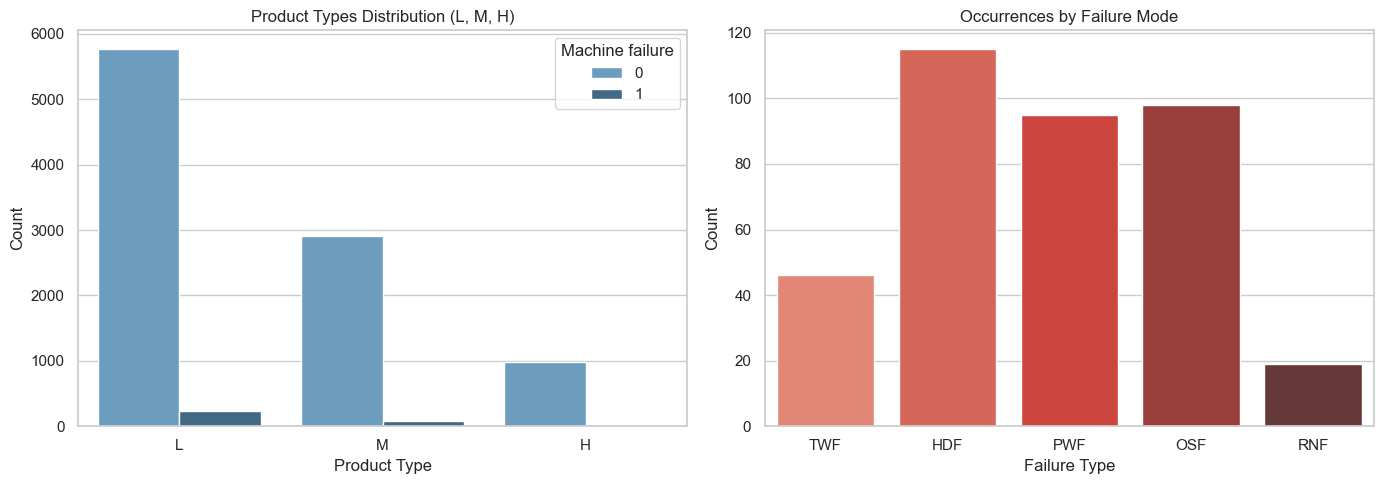

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Type',hue="Machine failure", order=['L', 'M', 'H'], ax=axes[0], palette='Blues_d')
axes[0].set_title("Product Types Distribution (L, M, H)")
axes[0].set_xlabel("Product Type")
axes[0].set_ylabel("Count")


failure_sums = df[failure_modes].sum().reset_index()
failure_sums.columns = ['Failure Mode', 'Count']
sns.barplot(data=failure_sums, x='Failure Mode', y='Count', ax=axes[1], palette='Reds_d')
axes[1].set_title("Occurrences by Failure Mode")
axes[1].set_xlabel("Failure Type")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# EDA

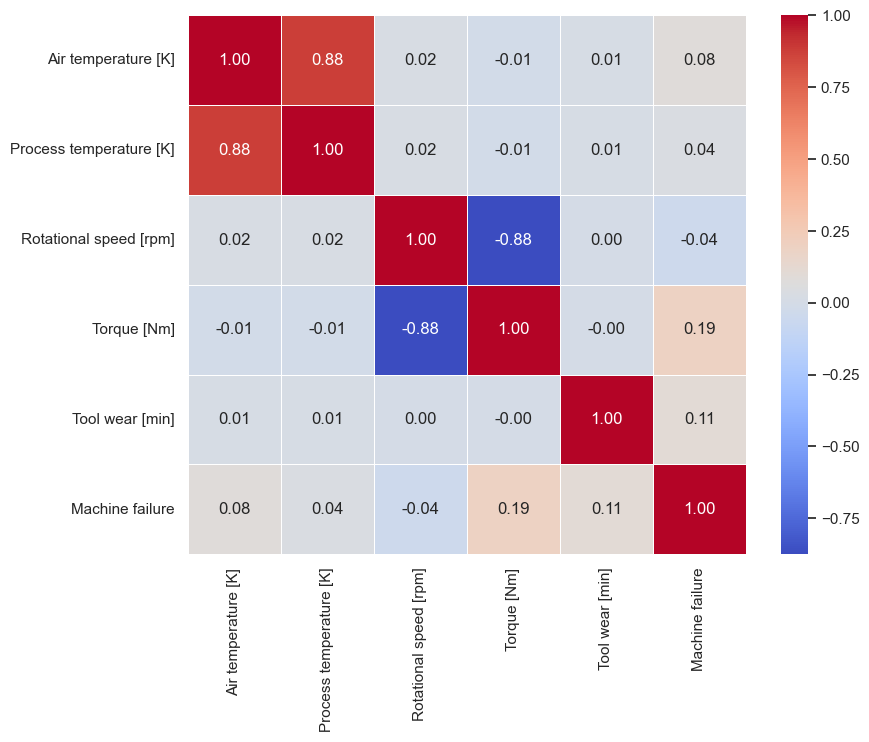

In [10]:
corr_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.show()

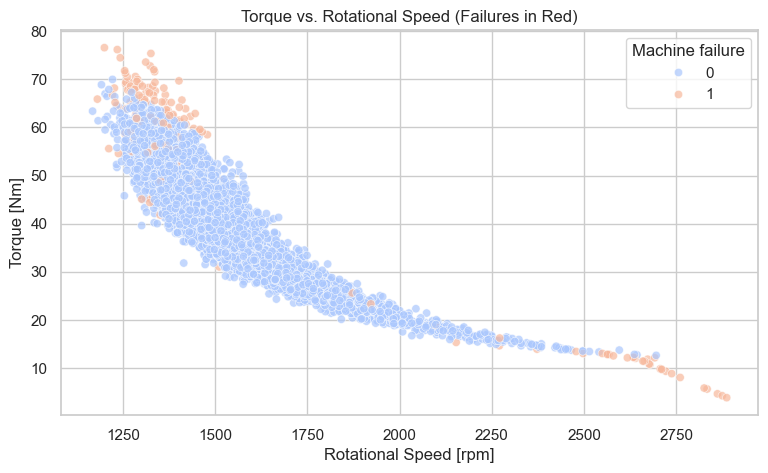

In [11]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    palette="coolwarm",
    alpha=0.7
)

plt.title("Torque vs. Rotational Speed (Failures in Red)")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.show()

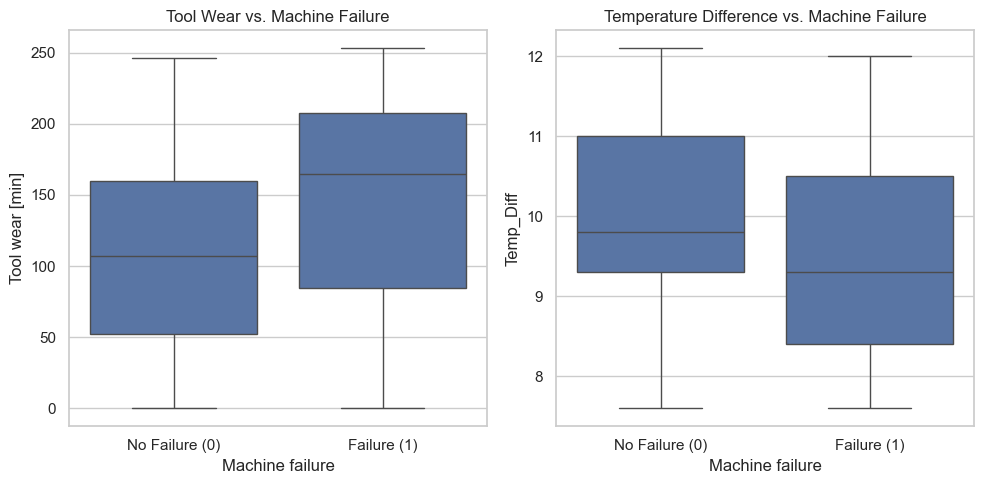

In [12]:
df['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(data=df, x='Machine failure', y='Tool wear [min]', ax=axes[0])
axes[0].set_title("Tool Wear vs. Machine Failure")
axes[0].set_xticklabels(['No Failure (0)', 'Failure (1)'])

sns.boxplot(data=df, x='Machine failure', y='Temp_Diff', ax=axes[1])
axes[1].set_title("Temperature Difference vs. Machine Failure")
axes[1].set_xticklabels(['No Failure (0)', 'Failure (1)'])

plt.tight_layout()
plt.show()

# Feature Engineering

In [13]:
df_prep = df.copy()
df_prep['Temp_Diff'] = df_prep['Process temperature [K]'] - df_prep['Air temperature [K]']
df_prep['Power_kW'] = df_prep['Torque [Nm]'] * (df_prep['Rotational speed [rpm]'] * (2 * np.pi / 60)) / 1000
df_prep['Strain'] = df_prep['Torque [Nm]'] * df_prep['Tool wear [min]']


In [14]:
df_prep[['Type', 'Temp_Diff', 'Power_kW', 'Strain']].head(10)

,Type,Temp_Diff,Power_kW,Strain
0,M,10.5,6.951591,0.0
1,L,10.5,6.826723,138.9
2,L,10.4,7.749388,247.0
3,L,10.4,5.927505,276.5
4,L,10.5,5.897817,360.0
5,M,10.5,6.252555,460.9
6,L,10.5,6.917703,593.6
7,L,10.5,6.428264,643.2
8,M,10.4,4.992640,514.8
9,M,10.5,5.104879,588.0


# Preprocessing

In [15]:
df_prep.drop(columns=['UDI', 'Product ID'], inplace=True, errors='ignore')

type_map = {'L': 0, 'M': 1, 'H': 2}
df_prep['Type'] = df_prep['Type'].map(type_map)

In [16]:
drop_targets = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
X = df_prep.drop(columns=drop_targets)
y_binary = df_prep['Machine failure']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [18]:
y_train.value_counts()

Machine failure
0    7729
1     271
Name: count, dtype: int64

# Cross Validation (Binary Classification)

In [ ]:
n_splits_binary = 5

cv_strategy_binary = StratifiedKFold(n_splits=n_splits_binary, shuffle=True, random_state=42)

cv_model_binary = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

cv_scoring_binary = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results_binary = cross_validate(
    cv_model_binary,
    X_train, y_train,
    cv=cv_strategy_binary,
    scoring=cv_scoring_binary,
    n_jobs=-1
)

print(f"Binary Classification - {n_splits_binary}-Fold Stratified Cross Validation Results")
print("-" * 60)
for metric in cv_scoring_binary:
    scores = cv_results_binary[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {scores.mean():.4f} ± {scores.std():.4f}")


# Models

In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

              precision    recall  f1-score   support

           0     0.9908    0.9990    0.9948      1932
           1     0.9615    0.7353    0.8333        68

    accuracy                         0.9900      2000
   macro avg     0.9761    0.8671    0.9141      2000
weighted avg     0.9898    0.9900    0.9894      2000



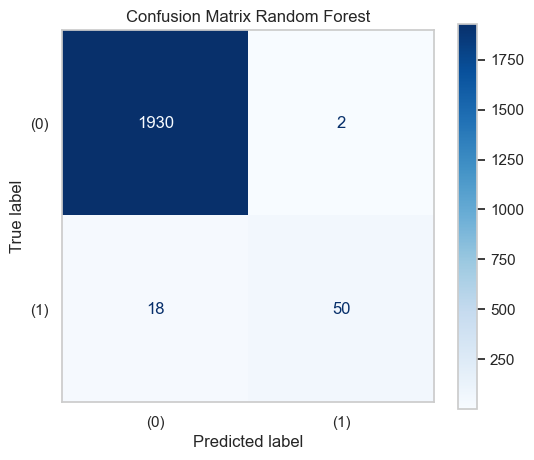

In [ ]:
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['(0)','(1)'],
    cmap='Blues',
    ax=ax
)
plt.title("Confusion Matrix Random Forest")
plt.grid(False)
plt.show()

              precision    recall  f1-score   support

           0     0.9938    0.9969    0.9953      1932
           1     0.9032    0.8235    0.8615        68

    accuracy                         0.9910      2000
   macro avg     0.9485    0.9102    0.9284      2000
weighted avg     0.9907    0.9910    0.9908      2000



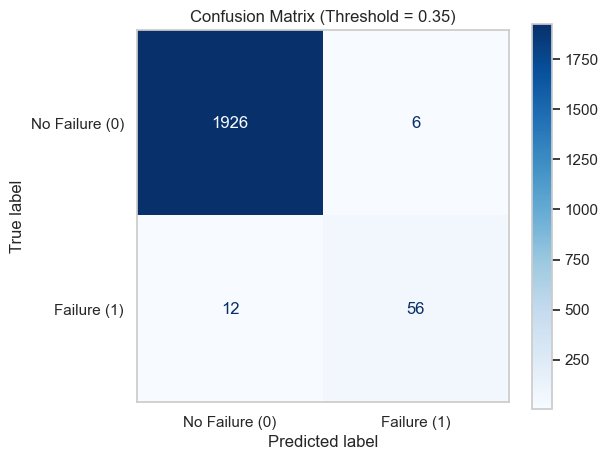

In [ ]:
# Probability of failure Happen
y_probs = rf_model.predict_proba(X_test)[:, 1]

custom_threshold = 0.35
y_pred_tuned = (y_probs >= custom_threshold).astype(int)


print(classification_report(y_test, y_pred_tuned, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=['No Failure (0)', 'Failure (1)'],
    cmap='Blues',
    ax=ax
)
plt.title(f"Confusion Matrix (Threshold = {custom_threshold})")
plt.grid(False)
plt.show()

# Model Comparison & Alternative Models

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best SVC Estimator's Params
{'svc__C': 50, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
              precision    recall  f1-score   support

           0     0.9897    0.9953    0.9925      1932
           1     0.8421    0.7059    0.7680        68

    accuracy                         0.9855      2000
   macro avg     0.9159    0.8506    0.8803      2000
weighted avg     0.9847    0.9855    0.9849      2000



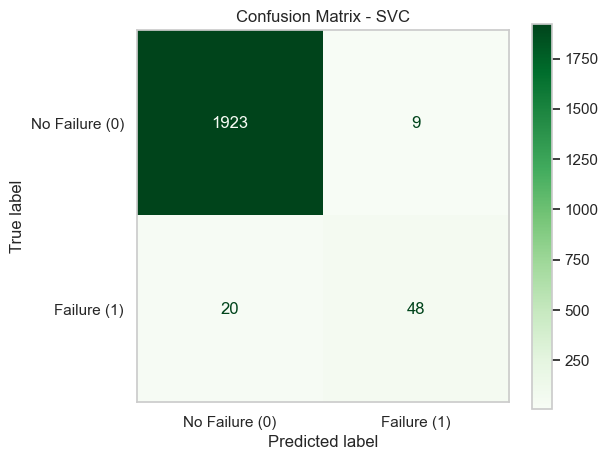

In [ ]:
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])


param_grid_svc = {
    'svc__C': [0.1, 1, 10, 50],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1],
    'svc__kernel': ['rbf']
}


stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svc = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid_svc,
    scoring='recall',
    cv=stratified_cv,
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train, y_train)

best_svc_model = grid_svc.best_estimator_
y_pred_svc = best_svc_model.predict(X_test)

print("Best SVC Estimator's Params")
print(grid_svc.best_params_)
print(classification_report(y_test, y_pred_svc, digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_svc, 
    display_labels=['No Failure (0)', 'Failure (1)'], 
    cmap='Greens', 
    ax=ax
)
plt.title("Confusion Matrix - SVC")
plt.grid(False)
plt.show()

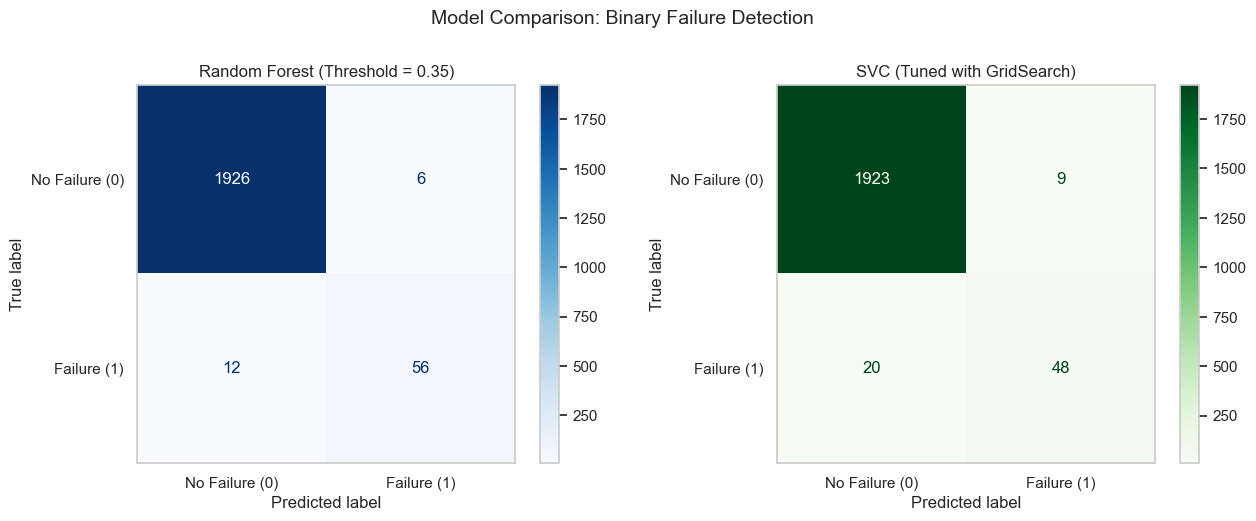

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))


ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_tuned,    
    display_labels=['No Failure (0)', 'Failure (1)'], 
    cmap='Blues', 
    ax=axes[0]
)
axes[0].set_title("Random Forest (Threshold = 0.35)")
axes[0].grid(False)


ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_svc, 
    display_labels=['No Failure (0)', 'Failure (1)'], 
    cmap='Greens', 
    ax=axes[1]
)
axes[1].set_title("SVC (Tuned with GridSearch)")
axes[1].grid(False)

plt.suptitle("Model Comparison: Binary Failure Detection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

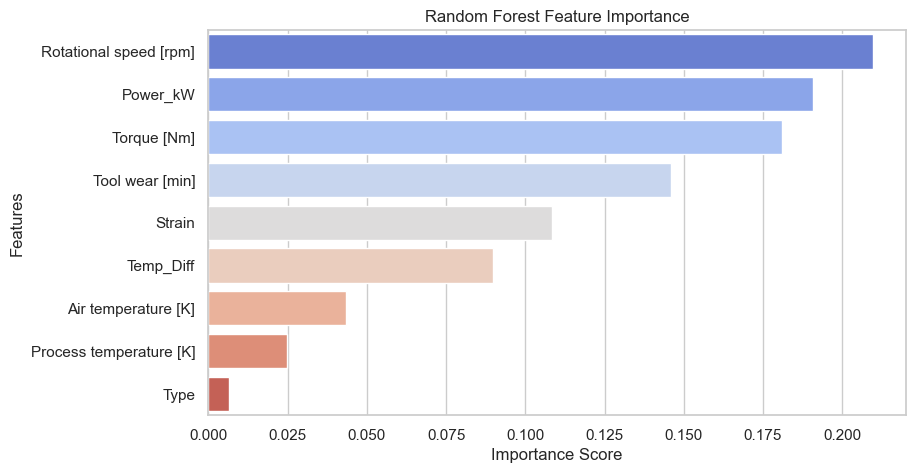

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, palette='coolwarm')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## Failure Type Identification

In [ ]:
def assign_failure_type(row):
    if row['TWF'] == 1:
        return 'TWF'
    elif row['HDF'] == 1:
        return 'HDF'
    elif row['PWF'] == 1:
        return 'PWF'
    elif row['OSF'] == 1:
        return 'OSF'
    elif row['RNF'] == 1:
        return 'RNF'
    else:
        return 'No Failure'

df_prep['Failure_Type'] = df_prep.apply(assign_failure_type, axis=1)

df_prep['Failure_Type'].value_counts()

Failure_Type
No Failure    9652
HDF            115
PWF             91
OSF             78
TWF             46
RNF             18
Name: count, dtype: int64

In [ ]:
y_multi_class = df_prep['Failure_Type']


X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_multi_class,
    test_size=0.2,
    random_state=42,
    stratify=y_multi_class
)

## Cross Validation (Multi-Class Failure Type)

In [ ]:
n_splits_multi = 5

cv_strategy_multi = StratifiedKFold(n_splits=n_splits_multi, shuffle=True, random_state=42)

cv_model_multi = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

cv_scoring_multi = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

cv_results_multi = cross_validate(
    cv_model_multi,
    X_tr, y_tr,
    cv=cv_strategy_multi,
    scoring=cv_scoring_multi,
    n_jobs=-1
)

print(f"Multi-Class Failure Type - {n_splits_multi}-Fold Stratified Cross Validation Results")
print("-" * 60)
for metric in cv_scoring_multi:
    scores = cv_results_multi[f'test_{metric}']
    label = metric.replace('_', ' ').capitalize()
    print(f"{label:18s}: {scores.mean():.4f} ± {scores.std():.4f}")


Multi-Class Failure Type - 5-Fold Stratified Cross Validation Results
------------------------------------------------------------
Accuracy          : 0.9902 ± 0.0012
F1 macro          : 0.6325 ± 0.0107
Precision macro   : 0.6415 ± 0.0092
Recall macro      : 0.6268 ± 0.0160


In [ ]:
rf_multi = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_multi.fit(X_tr, y_tr)
y_pred_multi = rf_multi.predict(X_te)

In [ ]:
print(classification_report(y_te, y_pred_multi, digits=4, zero_division=0))

              precision    recall  f1-score   support

         HDF     0.9200    1.0000    0.9583        23
  No Failure     0.9943    0.9990    0.9966      1930
         OSF     0.8889    1.0000    0.9412        16
         PWF     1.0000    1.0000    1.0000        18
         RNF     0.0000    0.0000    0.0000         4
         TWF     0.0000    0.0000    0.0000         9

    accuracy                         0.9925      2000
   macro avg     0.6339    0.6665    0.6494      2000
weighted avg     0.9862    0.9925    0.9893      2000



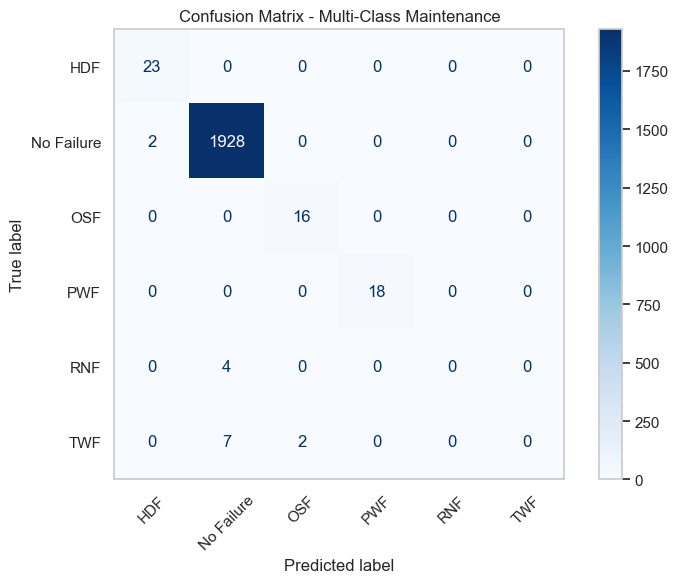

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_te,
    y_pred_multi,
    cmap='Blues',
    ax=ax,
    xticks_rotation=45
)
plt.title("Confusion Matrix - Multi-Class Maintenance")
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
def two_stage_maintenance_system(input_data, threshold=0.35):
    """
    Two-stage predictive maintenance system.
    """

    # Prepare the input data
    df_in = pd.DataFrame([input_data])

    type_map = {'L': 0, 'M': 1, 'H': 2}
    df_in['Type'] = df_in['Type'].map(type_map)

    # Create additional features
    df_in['Temp_Diff'] = df_in['Process temperature [K]'] - df_in['Air temperature [K]']
    df_in['Power_kW'] = df_in['Torque [Nm]'] * (df_in['Rotational speed [rpm]'] * (2 * np.pi / 60)) / 1000
    df_in['Strain'] = df_in['Torque [Nm]'] * df_in['Tool wear [min]']

    # Keep the same column order used for training
    df_in = df_in[X.columns]

    # -------------------------------
    # Stage 1: Check if there is a failure
    # -------------------------------
    prob_failure = rf_model.predict_proba(df_in)[0, 1]

    if prob_failure < threshold:
        return {
            "Stage 1 - Anomaly Check": "Machine is Normal",
            "Failure Probability": f"{prob_failure * 100:.2f}%"
        }

    # -------------------------------
    # Stage 2: Predict the fault type
    # -------------------------------
    multi_probs = rf_multi.predict_proba(df_in)[0]
    classes = rf_multi.classes_

    # Ignore the 'No Failure' class
    fault_prob_dict = {
        cls: prob for cls, prob in zip(classes, multi_probs) if cls != 'No Failure'
    }

    top_fault = max(fault_prob_dict, key=fault_prob_dict.get)
    top_fault_prob = fault_prob_dict[top_fault]

    recommendations = {
        'HDF': "Check the cooling system.",
        'PWF': "Inspect the power supply and motor load.",
        'OSF': "Reduce the operating load and check for overload.",
        'TWF': "Replace the worn cutting tool.",
        'RNF': "Inspect the machine before using it again."
    }

    return {
        "Stage 1 - Anomaly Check": "Possible machine failure detected.",
        "Failure Probability": f"{prob_failure * 100:.2f}%",
        "Stage 2 - Diagnosis": f"{top_fault} (Confidence: {top_fault_prob * 100:.2f}%)",
        "Detailed Fault Probabilities": {
            k: f"{v * 100:.1f}%"
            for k, v in fault_prob_dict.items()
        },
        "Action Plan": recommendations.get(top_fault, "Inspect the machine.")
    }

# Prediction

In [ ]:
normal_machine = {
    'Type': 'M',
    'Air temperature [K]': 298.1,
    'Process temperature [K]': 308.6,
    'Rotational speed [rpm]': 1551,
    'Torque [Nm]': 42.8,
    'Tool wear [min]': 0
}

res1 = two_stage_maintenance_system(normal_machine)

for k, v in res1.items():
    print(f"{k}: {v}")

Stage 1 - Anomaly Check: Machine is Normal
Failure Probability: 0.00%


In [ ]:
faulty_machine = {
    'Type': 'L',
    'Air temperature [K]': 298.9,
    'Process temperature [K]': 309.0,
    'Rotational speed [rpm]': 1250,
    'Torque [Nm]': 68.5,
    'Tool wear [min]': 210
}

res2 = two_stage_maintenance_system(faulty_machine)
for k, v in res2.items():
    print(f"{k}: {v}")

Stage 1 - Anomaly Check: Possible machine failure detected.
Failure Probability: 94.00%
Stage 2 - Diagnosis: OSF (Confidence: 68.00%)
Detailed Fault Probabilities: {'HDF': '12.0%', 'OSF': '68.0%', 'PWF': '13.0%', 'RNF': '0.0%', 'TWF': '3.0%'}
Action Plan: Reduce the operating load and check for overload.


In [ ]:
joblib.dump(rf_model, 'predictive_maintenance_binary.pkl')
joblib.dump(rf_multi, 'predictive_maintenance_multi.pkl')
joblib.dump(list(X.columns), 'predictive_maintenance_features.pkl')

print("Models and feature list saved successfully.")

Models and feature list saved successfully.
